# День 08. Упражнение 04
# Регрессия

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 1. Предобработка

1. Прочитай файл [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Заполни пропущенные значения нулями (`0`).
3. Раздели набор данных на обучающую и тестовую выборки с параметрами `test_size=0.2`.

In [3]:
df = pd.read_csv('../data/checker_regression.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          77 non-null     str    
 1   num_commits  77 non-null     int64  
 2   pageviews    59 non-null     float64
 3   AVG(diff)    18 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 2.5 KB


In [4]:
df

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN
5,user_1,62,28.0,NaN
6,user_10,20,89.0,NaN
7,user_10,20,89.0,NaN
8,user_10,20,89.0,NaN
9,user_10,20,89.0,NaN


Поскольку данные содержат повторяющиеся строки, нужно удалить дубликаты

In [5]:
df = df.drop_duplicates(keep='last').reset_index(drop=True)
df

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_10,20,89.0,NaN
2,user_11,7,NaN,-2.000000
3,user_12,86,NaN,-89.000000
4,user_13,52,NaN,-48.500000
5,user_14,61,143.0,NaN
6,user_15,23,NaN,-17.500000
7,user_16,41,NaN,-39.333333
8,user_17,51,47.0,NaN
9,user_18,5,3.0,NaN


In [6]:
df[['pageviews', 'AVG(diff)']] = df[['pageviews', 'AVG(diff)']].fillna(0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     str    
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.0 KB


In [7]:
X = df[['num_commits', 'pageviews']]
y = df['AVG(diff)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

## 2. Кросс-валидация

1. Напиши функцию `crossval`, которая принимает аргументы: `n_splits` для `KFold()`, `X`, `y`, модель (инициализированный класс с параметрами модели; не забудь о `random_state=21`) и возвращает для данного класса модели результат в таком виде:

```
train - 2696.4496895424836 | test - 1589.9979527104958
train - 2660.957874001452 | test - 2075.102636027137
train - 2847.315529246795 | test - 320.911928168403
train - 2500.7691099659237 | test - 4132.461382030178
train - 2643.927917295123 | test - 2237.8140952197878
train - 2396.295678819444 | test - 4509.650064742476
train - 2003.402267924976 | test - 8403.491474908551
train - 2531.876094212613 | test - 3135.944102735099
train - 2683.1795186023123 | test - 1796.01426292594
train - 2537.1192483996338 | test - 3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Запусти функцию для моделей `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. Параметры можешь выбрать самостоятельно, но тщательно убедись, что они подходят.

In [8]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        train_rmse = root_mean_squared_error(y_train, model.predict(X_train))
        test_rmse = root_mean_squared_error(y_test, model.predict(X_test))

        print(f'train - {train_rmse} | test - {test_rmse}')
        rmse_scores.append(test_rmse)

    print(f'Average RMSE on crossval is {np.mean(rmse_scores)}')

In [9]:
print('===Линейная регрессия===')
crossval(10, X, y, LinearRegression(n_jobs=-1))

===Линейная регрессия===
train - 61.35327112662008 | test - 57.85614740884658
train - 62.5462335194863 | test - 44.71218893425673
train - 61.14556371253599 | test - 83.19897138394585
train - 58.416728626194235 | test - 79.399015977114
train - 60.11026827841826 | test - 68.756146189296
train - 60.619323028395335 | test - 65.92296908962915
train - 61.72075104991357 | test - 61.800360553015715
train - 62.60680682836641 | test - 46.68994292992783
train - 55.58034321272078 | test - 99.08124434288634
train - 61.577932451061805 | test - 53.24118830442656
Average RMSE on crossval is 66.06581751133447


In [10]:
print('===Дерево решений===')
crossval(10, X, y, DecisionTreeRegressor(max_depth=10, random_state=21))

===Дерево решений===
train - 0.0 | test - 117.17718934888181
train - 0.0 | test - 79.5333147061541
train - 0.0 | test - 0.0
train - 0.0 | test - 78.98656472722058
train - 0.0 | test - 101.36705213854874
train - 0.0 | test - 35.38836908740875
train - 0.0 | test - 0.0
train - 0.0 | test - 69.81014730443323
train - 0.0 | test - 117.52949078296776


train - 0.0 | test - 40.58792924010783
Average RMSE on crossval is 64.03800573357229


In [11]:
print('===Случайный лес===')
crossval(10, X, y, RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21))

===Случайный лес===
train - 20.920695939881494 | test - 97.50335139862099
train - 22.513709875327706 | test - 78.01690371916807
train - 26.45753874793136 | test - 20.678674351271315


train - 24.801579078915356 | test - 56.688591592495406
train - 22.400454654459477 | test - 77.74492463343996
train - 23.84950304426348 | test - 53.93331786876579
train - 24.960042347292447 | test - 8.141221739804578


train - 24.33125738694806 | test - 57.41679402832187
train - 21.748562307626617 | test - 91.24344940546369
train - 26.400345641306533 | test - 32.155805517822095
Average RMSE on crossval is 57.35230342551737


## 3. Предсказания и оценка

1. Сделай предсказания на тестовом наборе данных для каждой из трёх моделей с финальными параметрами.
2. Построй график для каждой модели, где по оси x — фактическая средняя разница, а по оси y — предсказание модели.
3. Как должен выглядеть график в идеальном случае? Напиши ответ в markdown-ячейке в конце раздела.

In [12]:
model_linear = LinearRegression(n_jobs=-1)
model_linear.fit(X_train, y_train)
predict_linear = model_linear.predict(X_test)

In [13]:
model_tree = DecisionTreeRegressor(max_depth=10, random_state=21)
model_tree.fit(X_train, y_train)
predict_tree = model_tree.predict(X_test)

In [14]:
model_random_forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21)
model_random_forest.fit(X_train, y_train)
predict_random_forest = model_random_forest.predict(X_test)

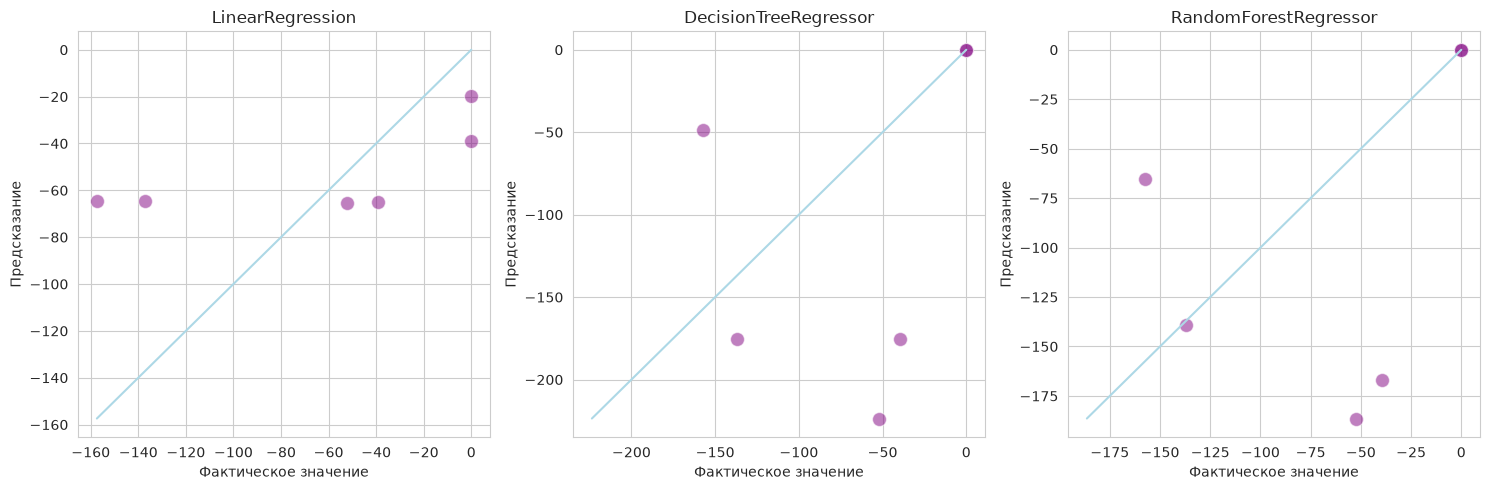

In [15]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    (predict_linear, 'LinearRegression'),
    (predict_tree, 'DecisionTreeRegressor'),
    (predict_random_forest, 'RandomForestRegressor'),
]

for ax, (y_pred, title) in zip(axes, models):
    sns.scatterplot(x=y_test.values, y=y_pred, alpha=0.5, color='purple', s=100, ax=ax)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='lightblue')
    ax.set_xlabel('Фактическое значение')
    ax.set_ylabel('Предсказание')
    ax.set_title(title)

plt.tight_layout()
plt.show()

В идеальном случае точки должны лежать на главной диагонали y=x, поскольку фактическое значение должно совпадать с предсказанным